<a href="https://colab.research.google.com/github/hdflorez/Entrega_4/blob/main/Ej5_HR_Analytics_Employee_Attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis de Datos | 190304018-1 | 2026-1** | **Entrega 4** |

**Integrantes - Equipo 8:**
*   Mariana Villegas Ochoa
*   Melisa Colorado Soto
*   Jaider Santiago Villa David
*   Hernán Darío Flórez Martínez
---

# **Dataset: HR Analytics Employee Attrition**
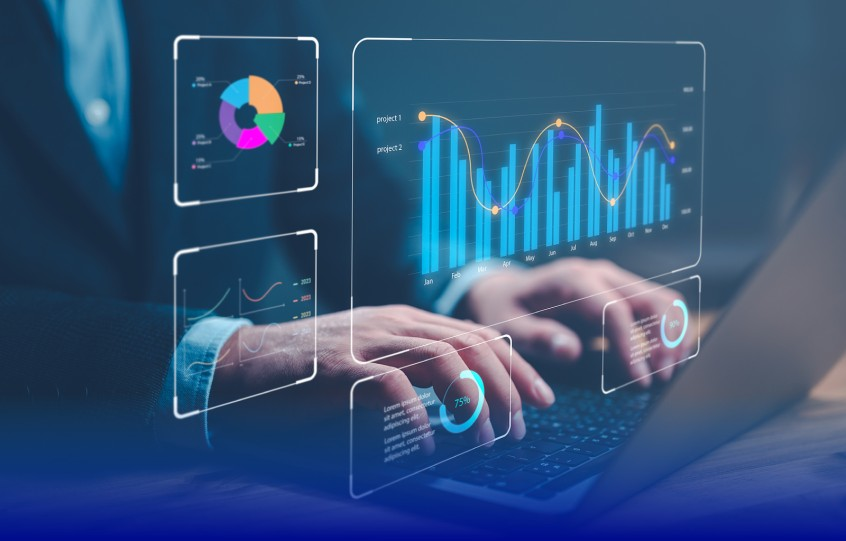

Recuperado de Kaggle: https://www.kaggle.com/datasets/giripujar/hr-analytics

# **1. Configuración inicial**




In [ ]:
#Instalación de dependencias y descarga del dataset
import kagglehub
from kagglehub import KaggleDatasetAdapter

#Ruta de acceso al archivo
file_path = "HR_comma_sep.csv"

#Cargar la última versión del dataset
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "giripujar/hr-analytics",
  file_path,
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'hr-analytics' dataset.
First 5 records:    satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              

In [ ]:
#Importe de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import ( LabelEncoder, StandardScaler)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, classification_report,
                            confusion_matrix,ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [ ]:
# Composición de dataset
print("Dimensiones del dataset:")
print(df.shape)

print("\nColumnas:")
print(df.columns)

print("\nTipos de datos:")
df.info()

Dimensiones del dataset:
(14999, 10)

Columnas:
Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

Tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 149

# **2. Análisis Exploratorio de Datos (EDA)**


In [ ]:
# Etiquetas (permanece, abandona)
df['abandono'] = df['left'].map({
    0: 'Permanece',
    1: 'Abandona'
})

df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary,abandono
0,0.38,0.53,2,157,3,0,1,0,sales,low,Abandona
1,0.80,0.86,5,262,6,0,1,0,sales,medium,Abandona
2,0.11,0.88,7,272,4,0,1,0,sales,medium,Abandona
3,0.72,0.87,5,223,5,0,1,0,sales,low,Abandona
4,0.37,0.52,2,159,3,0,1,0,sales,low,Abandona


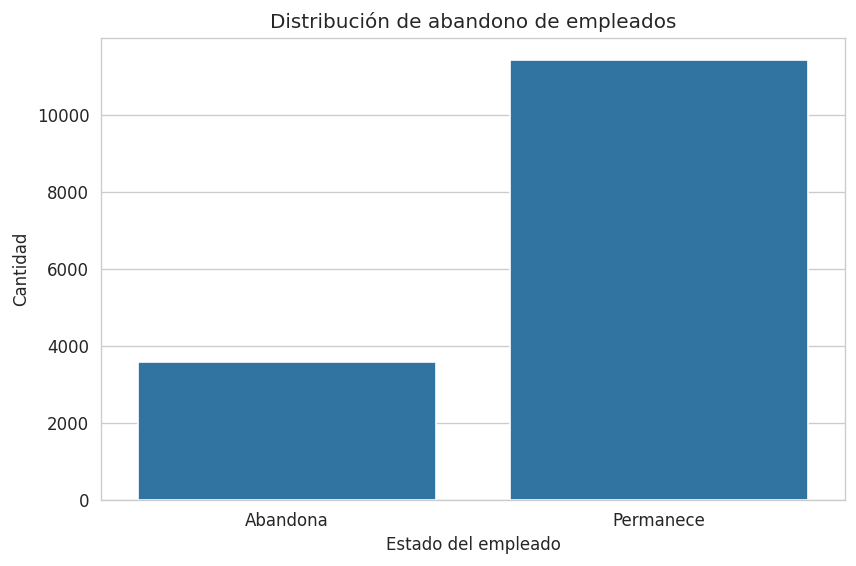

In [ ]:
# Distribución del abandono de empleados
sns.countplot(
    x='abandono',
    data=df
)

plt.title('Distribución de abandono de empleados')
plt.xlabel('Estado del empleado')
plt.ylabel('Cantidad')

plt.show()

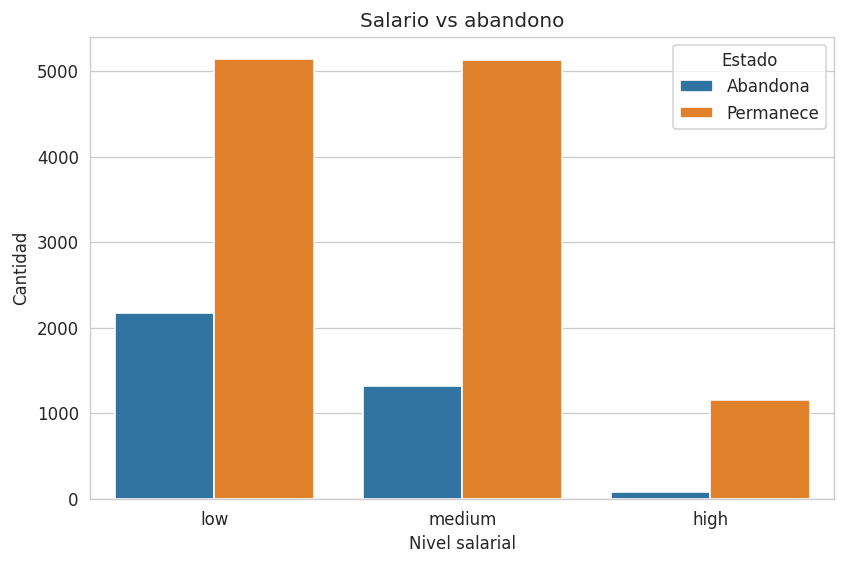

In [ ]:
# Salario vs abandono
sns.countplot(
    x='salary',
    hue='abandono',
    data=df
)

plt.title('Salario vs abandono')
plt.xlabel('Nivel salarial')
plt.ylabel('Cantidad')
plt.legend(title='Estado')

plt.show()

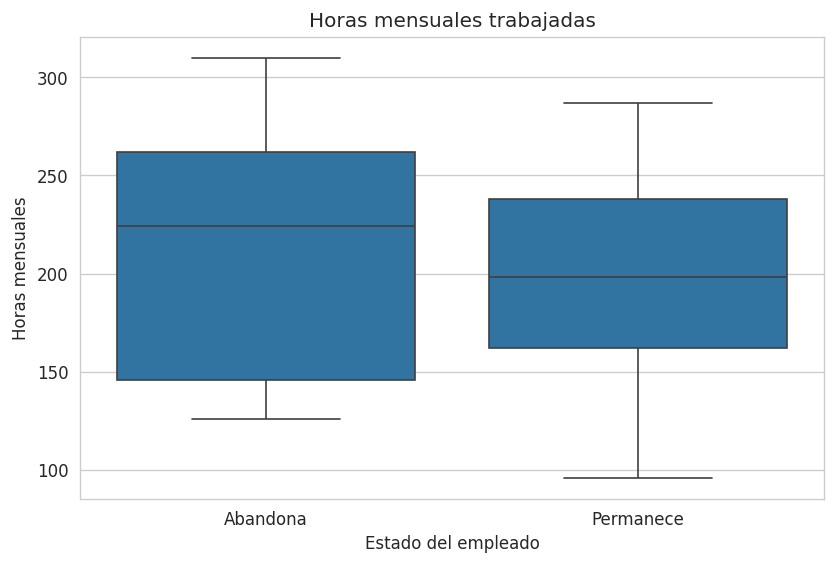

In [ ]:
# Horas mensuales trabajadas vs abandono
sns.boxplot(
    x='abandono',
    y='average_montly_hours',
    data=df
)

plt.title('Horas mensuales trabajadas')
plt.xlabel('Estado del empleado')
plt.ylabel('Horas mensuales')

plt.show()

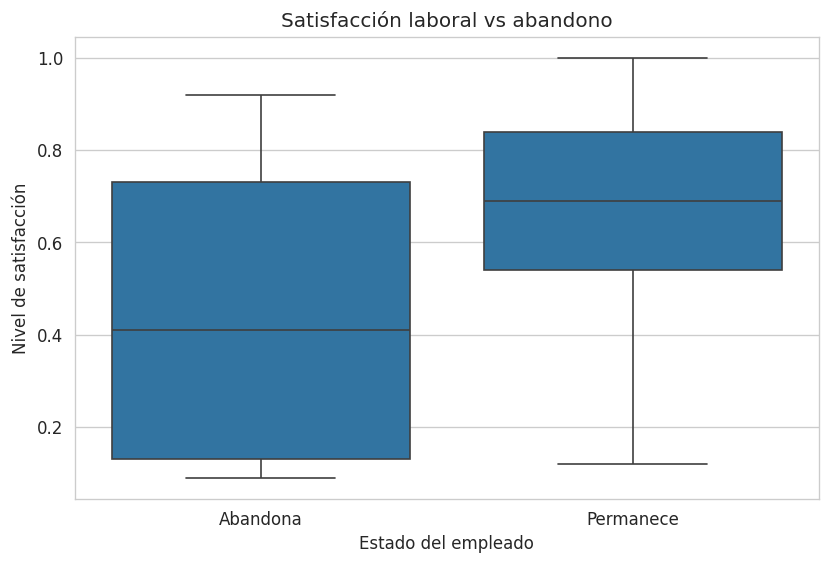

In [ ]:
# Satisfacción laboral vs abandono
sns.boxplot(
    x='abandono',
    y='satisfaction_level',
    data=df
)

plt.title('Satisfacción laboral vs abandono')
plt.xlabel('Estado del empleado')
plt.ylabel('Nivel de satisfacción')

plt.show()

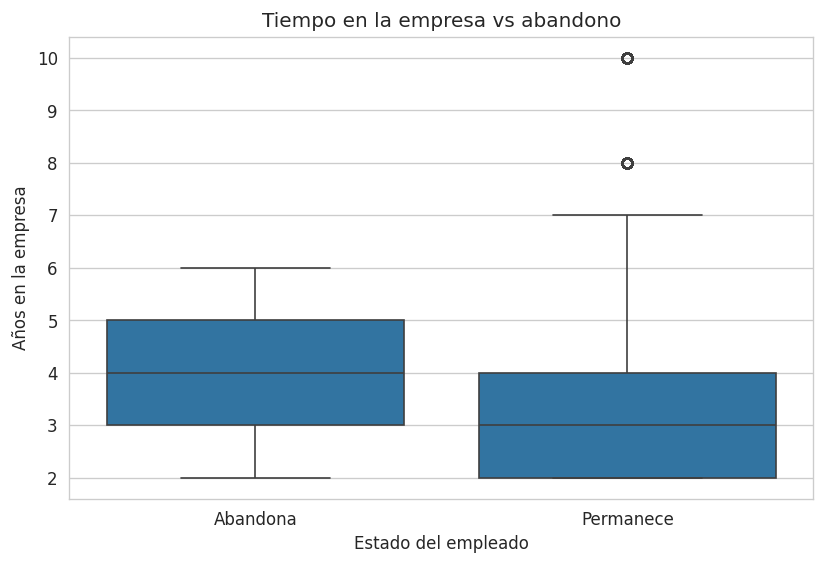

In [ ]:
# Tiempo en la empresa vs abandono
sns.boxplot(
    x='abandono',
    y='time_spend_company',
    data=df
)

plt.title('Tiempo en la empresa vs abandono')
plt.xlabel('Estado del empleado')
plt.ylabel('Años en la empresa')

plt.show()

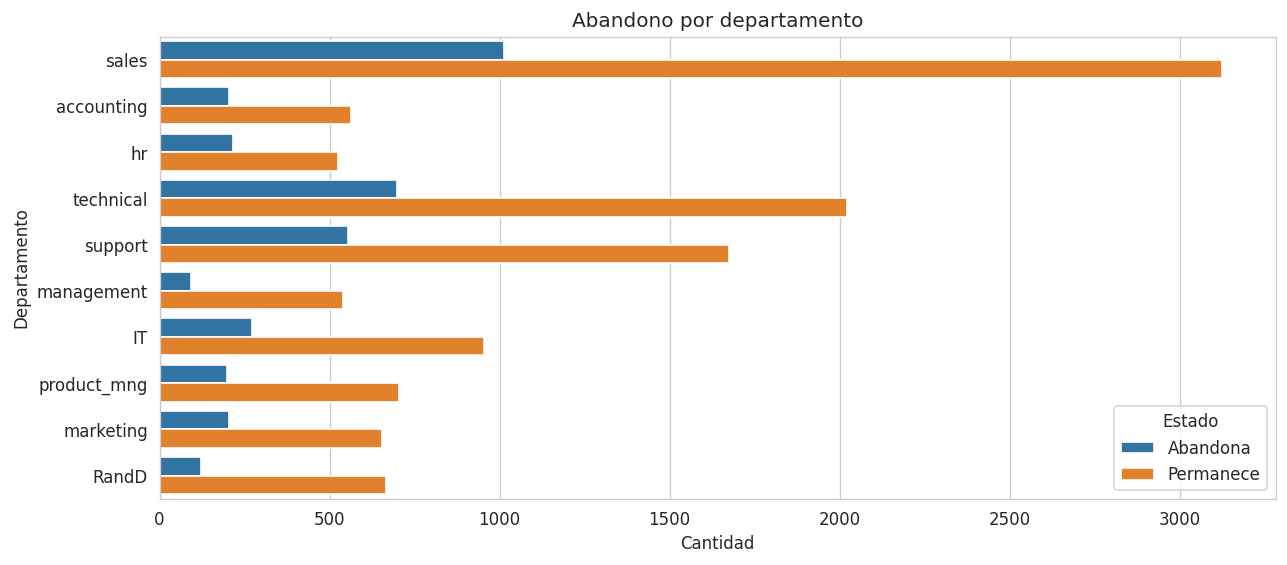

In [ ]:
# Abandono por departamento
plt.figure(figsize=(12,5))
sns.countplot(
    y='Department',
    hue='abandono',
    data=df
)

plt.title('Abandono por departamento')
plt.xlabel('Cantidad')
plt.ylabel('Departamento')
plt.legend(title='Estado')

plt.show()

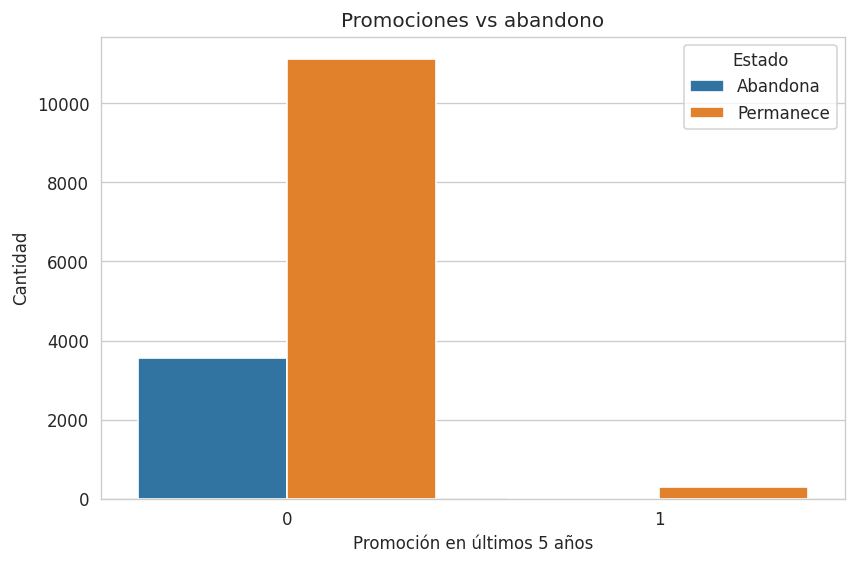

In [ ]:
# Promociones vs abandono
sns.countplot(
    x='promotion_last_5years',
    hue='abandono',
    data=df
)

plt.title('Promociones vs abandono')
plt.xlabel('Promoción en últimos 5 años')
plt.ylabel('Cantidad')
plt.legend(title='Estado')

plt.show()

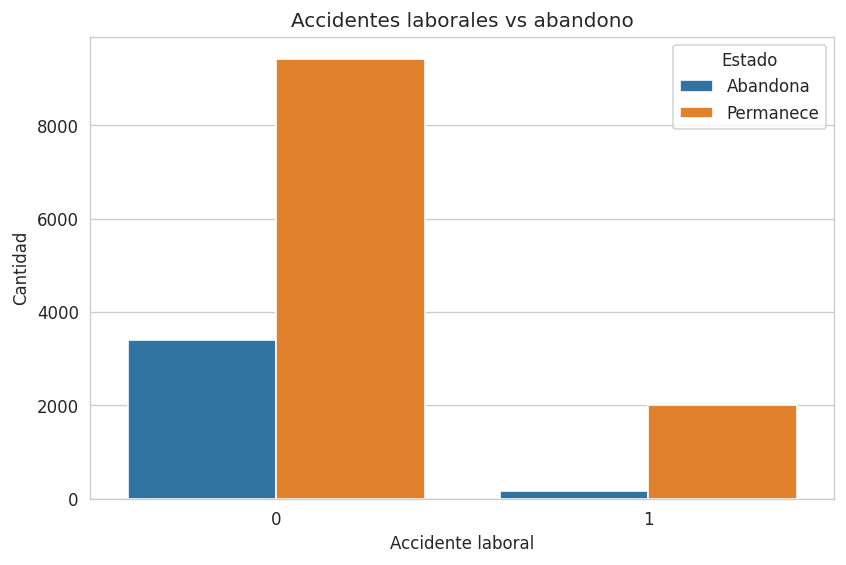

In [ ]:
# Accidentes laborales vs abandono
sns.countplot(
    x='Work_accident',
    hue='abandono',
    data=df
)

plt.title('Accidentes laborales vs abandono')
plt.xlabel('Accidente laboral')
plt.ylabel('Cantidad')
plt.legend(title='Estado')

plt.show()

# **3. Procesamiento de datos**

In [ ]:
# Preprocesamiento

# Separar variable objetivo
X = df.drop("left", axis=1)
y = df["left"]

# Convertir variables categóricas a numéricas
X = pd.get_dummies(X, drop_first=True)

# Escalado
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Preprocesamiento completado.")

Preprocesamiento completado.


In [ ]:
# División de datos

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (11999, 19)
Prueba: (3000, 19)


# **4. Entrenamiento y Evaluación de Modelos supervisados: Regresión Logística, Árboles de Decisión y Random Forest.**

===== Regresión Logística =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2294
           1       1.00      1.00      1.00       706

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

Accuracy: 1.0
F1-Score: 1.0
ROC-AUC: 1.0


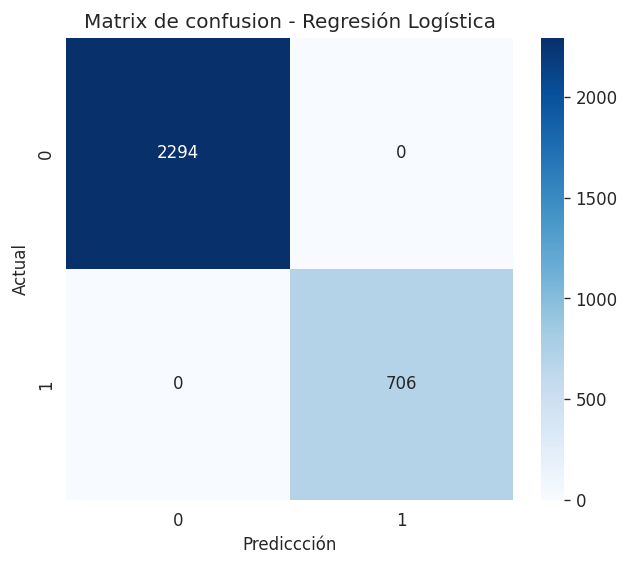

In [ ]:
# Regresión Logística

# Modelo
lr_model = LogisticRegression(max_iter=1000)

# Entrenamiento
lr_model.fit(X_train, y_train)

# Predicciones
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:,1]

# Métricas
print("===== Regresión Logística =====")
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1-Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

# Matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Gráfica
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matrix de confusion - Regresión Logística")
plt.xlabel("Prediccción")
plt.ylabel("Actual")

plt.show()

===== Árboles de Decisión =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2294
           1       1.00      1.00      1.00       706

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

Accuracy: 1.0
F1-Score: 1.0
ROC-AUC: 1.0


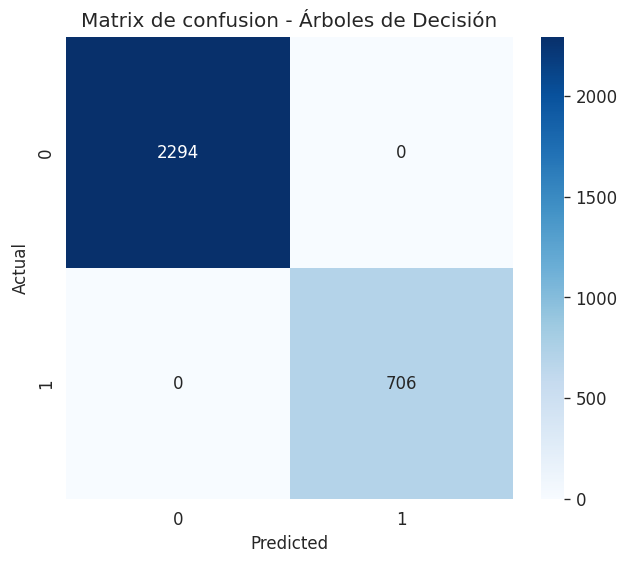

In [ ]:
# Árboles de Decisión

# Modelo
dt_model = DecisionTreeClassifier(
    random_state=42)

# Entrenamiento
dt_model.fit(X_train, y_train)

# Predicciones
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

# Métricas
print("===== Árboles de Decisión =====")

print(classification_report(y_test, y_pred_dt))

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("F1-Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

# Matriz de confusión
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Gráfica
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matrix de confusion - Árboles de Decisión")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

===== RANDOM FOREST =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2294
           1       1.00      1.00      1.00       706

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

Accuracy: 1.0
F1-Score: 1.0
ROC-AUC: 1.0


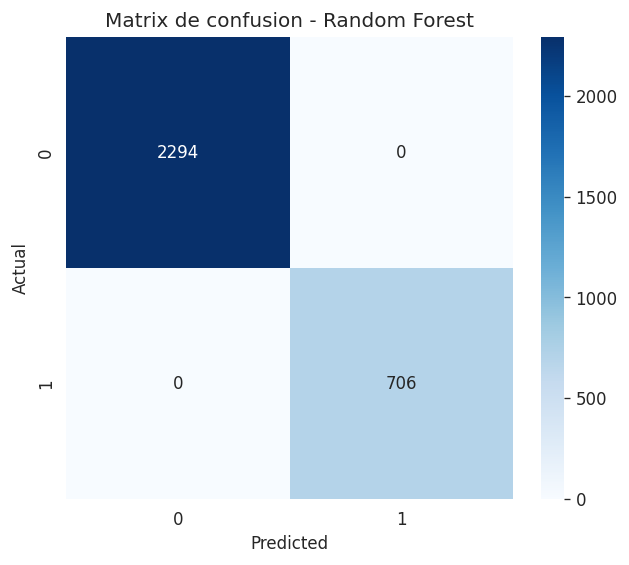

In [ ]:
# Random Forest

# Modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entrenamiento
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# Métricas
print("===== RANDOM FOREST =====")

print(classification_report(y_test, y_pred_rf))

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Gráfica
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matrix de confusion - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# **5. Comparación de modelos**

                Modelo  Accuracy  F1-Score  ROC-AUC
0  Regresión Logística       1.0       1.0      1.0
1    Árbol de Decisión       1.0       1.0      1.0
2        Random Forest       1.0       1.0      1.0


<Figure size 1200x720 with 0 Axes>

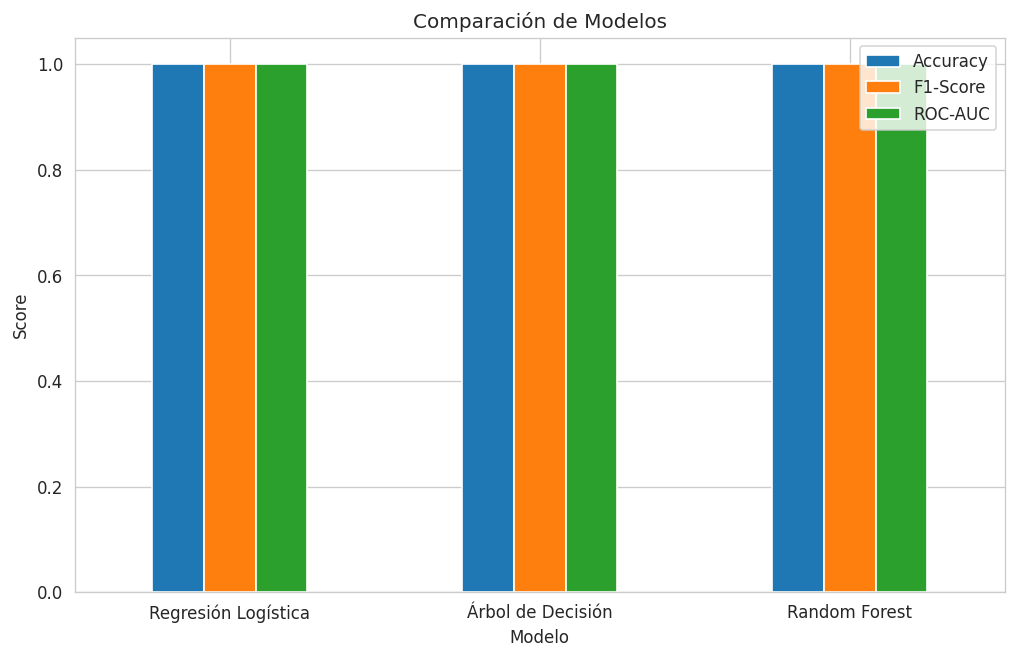

In [ ]:
#Comparación de modelos
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Árbol de Decisión",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],

    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

# Organizar de mejor a peor según F1-Score
comparacion_modelos = comparacion_modelos.sort_values(
    by="F1-Score",
    ascending=False
)

# Mostrar tabla
print(comparacion_modelos)

#Grafica
plt.figure(figsize=(10,6))
comparacion_modelos.set_index("Modelo").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparación de Modelos")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

# **8.  Propuesta de acciones preventivas**

- **Fortalecer el bienestar laboral integral**: implementar programas de salud mental, pausas activas y acompañamiento psicosocial para equipos con mayor riesgo de rotación.
- **Gestionar la carga de trabajo y prevenir burnout**: establecer límites sobre horas extra, monitorear picos de trabajo por área y redistribuir tareas cuando se detecten sobrecargas.
- **Diseñar rutas de crecimiento profesional**: definir planes de carrera por rol, con metas semestrales, mentorías y criterios claros de promoción interna.
- **Crear un sistema de escucha continua del empleado**: aplicar encuestas de clima y satisfacción de forma periódica, analizar resultados por departamento y ejecutar planes de mejora con responsables y fechas.
- **Actualizar la propuesta de compensación y beneficios**: revisar competitividad salarial por mercado, incorporar beneficios flexibles y priorizar ajustes en perfiles críticos.
- **Implementar intervenciones focalizadas basadas en datos**: usar el modelo predictivo para identificar grupos de alto riesgo y activar acciones preventivas tempranas (reuniones de seguimiento, ajustes de rol y planes de retención).

# **9.  Conclusiones**

- El modelo **Random Forest** obtuvo el mejor rendimiento entre los algoritmos evaluados, lo que confirma su capacidad para capturar relaciones no lineales en el fenómeno de rotación.
- Las variables con mayor influencia en la predicción fueron la **satisfacción laboral**, las **horas mensuales trabajadas**, el **tiempo en la empresa** y el **nivel salarial**; estas dimensiones deben considerarse prioritarias en la estrategia de retención.
- El uso de técnicas de **Machine Learning** permite anticipar casos con alta probabilidad de abandono y pasar de una gestión reactiva a una gestión preventiva del talento.
- La analítica predictiva debe complementarse con políticas de gestión humana (bienestar, desarrollo y compensación) para generar impacto sostenible.
- Como siguiente paso, se recomienda implementar un **tablero de seguimiento** con indicadores de rotación y reentrenar el modelo periódicamente para mantener su precisión frente a cambios organizacionales.